In [11]:
import pandas as pd
import glob
import os
import bramlib

In [3]:
def create_df(file):
    df = pd.read_csv(file)
    user_id = os.path.basename(file).split(".")[0]
    user_id = int(user_id[1:])
    df["user_id"] = user_id
    return df

def combine_folder(folder, limit=-1):
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    df_list = []
    
    n = 0
    for file in all_files[:limit]:
        df = create_df(file=file)
        df_list.append(df)

        n += 1
        if n % 100 == 0:
            print(r"Currently on:{0}", n)

    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

def get_other_folders(folders, df):
    valid_users = df["user_id"].unique()
    dfs = []

    for folder in folders:
        files = glob.glob(os.path.join(folder, "*.csv"))
        for file in files:
            userc = os.path.basename(file).split(".")[0]
            userc_id = int(userc[1:])

            if userc_id in valid_users:
                df = create_df(file)
                dfs.append(df)
    combined_df = pd.concat(dfs, ignore_index=True)
    return combined_df


In [4]:
df = combine_folder(r"C:\Users\bramm\student-grade data\Data\raw\EdNet-KT1\KT1", 1000)
df.head(10)

Currently on:{0} 100
Currently on:{0} 200
Currently on:{0} 300
Currently on:{0} 400
Currently on:{0} 500
Currently on:{0} 600
Currently on:{0} 700
Currently on:{0} 800
Currently on:{0} 900
Currently on:{0} 1000


,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
0,1565096190868,1,q5012,b,38000,1
1,1565096221062,2,q4706,c,24000,1
2,1565096293432,3,q4366,b,68000,1
3,1565096339668,4,q4829,a,42000,1
4,1565096401774,5,q6528,b,59000,1
5,1565096463370,6,q4793,a,58000,1
6,1565096501746,7,q6488,a,35000,1
7,1565097101361,8,q356,b,23000,1
8,1565097171393,9,q1382,c,22000,1
9,1565097240758,10,q830,b,25000,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260019 entries, 0 to 260018
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   timestamp     260019 non-null  int64
 1   solving_id    260019 non-null  int64
 2   question_id   260019 non-null  str  
 3   user_answer   260008 non-null  str  
 4   elapsed_time  260019 non-null  int64
 5   user_id       260019 non-null  int64
dtypes: int64(4), str(2)
memory usage: 13.4 MB


In [6]:
df.describe()

,timestamp,solving_id,elapsed_time,user_id
count,2.600190e+05,260019.000000,2.600190e+05,260019.000000
mean,1.540503e+12,942.433880,2.636158e+04,61769.245171
std,2.169905e+10,1169.244105,5.283649e+04,45095.081979
min,1.510481e+12,1.000000,0.000000e+00,1.000000
25%,1.518054e+12,152.000000,1.533300e+04,10052.000000
50%,1.536068e+12,522.000000,2.000000e+04,100107.000000
75%,1.564442e+12,1309.000000,2.925000e+04,100581.000000
max,1.575280e+12,7772.000000,1.349900e+07,100901.000000


In [7]:
folders = [
    r"C:\\Users\\bramm\\student-grade data\\Data\\raw\\EdNet-KT2\\KT2",
    r"C:\\Users\\bramm\\student-grade data\\Data\\raw\\EdNet-KT3\\KT3",
    r"C:\\Users\\bramm\\student-grade data\\Data\\raw\\EdNet-KT4\\KT4"    
]
df = get_other_folders(folders, df)
df.head(10)


,timestamp,action_type,item_id,source,user_answer,platform,user_id,cursor_time
0,1565096151269,enter,b3544,diagnosis,NaN,mobile,1,NaN
1,1565096187972,respond,q5012,diagnosis,b,mobile,1,NaN
2,1565096194904,submit,b3544,diagnosis,NaN,mobile,1,NaN
3,1565096195001,enter,b3238,diagnosis,NaN,mobile,1,NaN
4,1565096218682,respond,q4706,diagnosis,c,mobile,1,NaN
5,1565096223029,submit,b3238,diagnosis,NaN,mobile,1,NaN
6,1565096223119,enter,b2898,diagnosis,NaN,mobile,1,NaN
7,1565096290094,respond,q4366,diagnosis,b,mobile,1,NaN
8,1565096295925,submit,b2898,diagnosis,NaN,mobile,1,NaN
9,1565096296012,enter,b3361,diagnosis,NaN,mobile,1,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 339238 entries, 0 to 339237
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   timestamp    339238 non-null  int64  
 1   action_type  339238 non-null  str    
 2   item_id      339238 non-null  str    
 3   source       339216 non-null  str    
 4   user_answer  84100 non-null   object 
 5   platform     339216 non-null  str    
 6   user_id      339238 non-null  int64  
 7   cursor_time  31958 non-null   float64
dtypes: float64(1), int64(2), object(1), str(4)
memory usage: 28.1+ MB


--- Missing Data Report for df ---
Total Data Points: 2713904
Total Missing Data Points: 562462
Overall Missing Data: 20.73%

Missing Data Per Column (%):


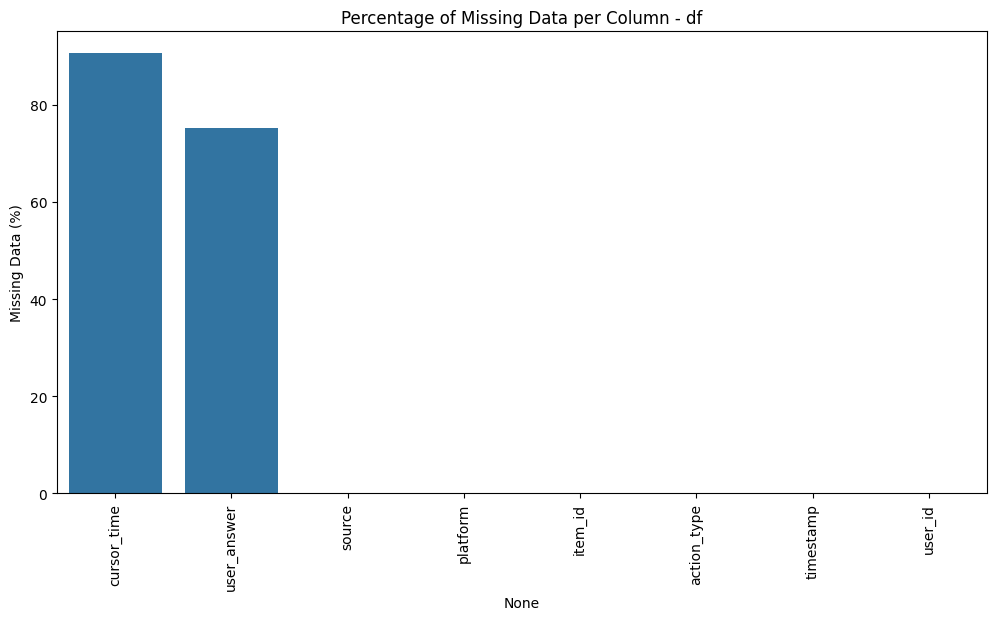

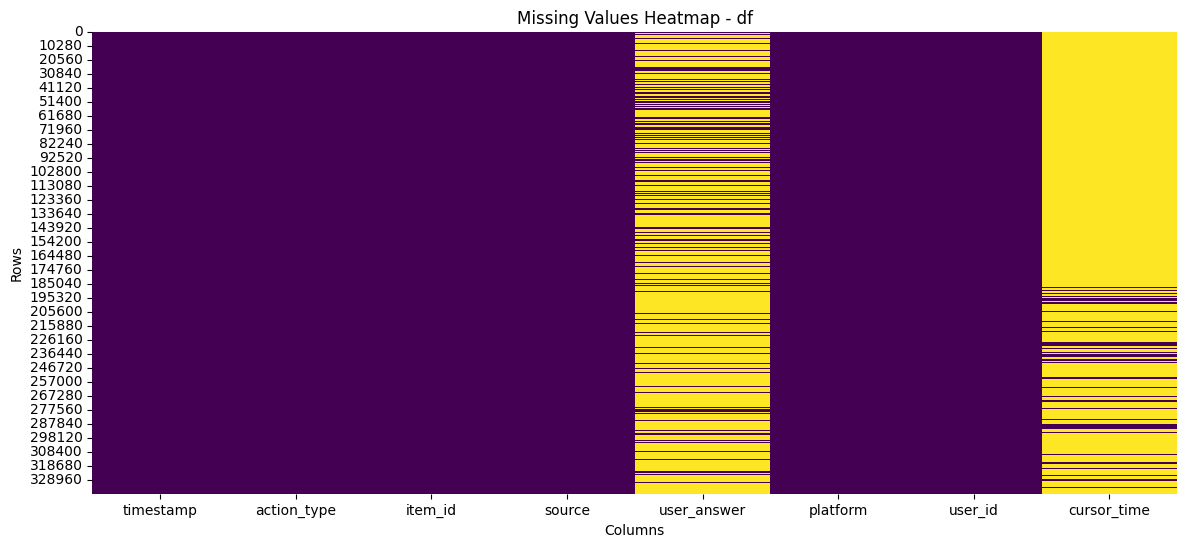

In [12]:
bramlib.analyze_missing_data(df, True)